In [1]:
import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

try:
    import missingno as msno
except Exception:
    msno = None

import scipy.stats as stats
import statsmodels.api as sm

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder,
    PowerTransformer
)

from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif,
    mutual_info_regression,
    f_classif,
    RFE
)
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None

try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 0xBEEF # gogu 😛

In [2]:
"""
Load and preview the YouTube dataset
"""
csv_path = "youtube_viewcount.csv"
data = pd.read_csv(csv_path)
data.head(5)

,channelId,channelTitle,videoId,publishedAt,publishedAtSQL,videoTitle,videoDescription,videoCategoryId,videoCategoryLabel,duration,durationSec,dimension,definition,caption,thumbnail_maxres,licensedContent,viewCount,likeCount,dislikeCount,favoriteCount,commentCount
0,UCkndrGoNpUDV-uia6a9jwVg,ExcelIsFun,Z2Cy9IY7IBA,2020-08-20T20:39:38Z,20/8/20 20:39,Add 500 to All Numbers in Text String? LET or ...,Download Excel File: http://excelisfun.net/fil...,27,Education,PT11M51S,711,2d,hd,False,\N,1,0,22,0,0,4
1,UCkndrGoNpUDV-uia6a9jwVg,ExcelIsFun,oS_tUs51T0A,2020-08-17T21:23:13Z,17/8/20 21:23,Dynamic Excel Multiplication Table with Condit...,Download Excel File: http://excelisfun.net/fil...,27,Education,PT7M59S,479,2d,hd,False,\N,1,5027,396,0,0,83
2,UCkndrGoNpUDV-uia6a9jwVg,ExcelIsFun,yvmdIX9ZsPA,2020-08-14T15:02:25Z,14/8/20 15:02,Dueling Excel 191: Net Working Hours Spanning ...,Download Excel File: http://excelisfun.net/fil...,27,Education,PT17M11S,1031,2d,hd,False,\N,1,4668,206,1,0,66
3,UCkndrGoNpUDV-uia6a9jwVg,ExcelIsFun,08kgJ8WM_Q0,2020-08-10T19:13:08Z,10/8/2020 19:13,Append Two Number Columns and Sort. Excel Magi...,Download Excel File: http://excelisfun.net/fil...,27,Education,PT5M10S,310,2d,hd,False,\N,1,5375,472,3,0,114
4,UCkndrGoNpUDV-uia6a9jwVg,ExcelIsFun,h-qLNikIs-0,2020-08-03T22:44:45Z,3/8/2020 22:44,LET Function Advanced Array Formula for Dynami...,Download Excel File: http://excelisfun.net/fil...,27,Education,PT14M32S,872,2d,hd,False,\N,1,5802,313,1,0,132


In [3]:
"""
Check dataset dimensions
"""
data.shape

(44261, 21)

In [4]:
"""
Inspect column data types
"""
data.dtypes

channelId             object
channelTitle          object
videoId               object
publishedAt           object
publishedAtSQL        object
videoTitle            object
videoDescription      object
videoCategoryId       object
videoCategoryLabel    object
duration              object
durationSec           object
dimension             object
definition            object
caption               object
thumbnail_maxres      object
licensedContent       object
viewCount             object
likeCount             object
dislikeCount          object
favoriteCount         object
commentCount          object
dtype: object

In [5]:
"""
Replace placeholder values with NaN
"""
data = data.replace('\\N', np.nan)

In [6]:
"""
Drop unnecessary columns for modeling
"""
drop_columns = ["channelId", "videoId" ,"videoTitle", "videoDescription",
                "dimension", "thumbnail_maxres", "licensedContent",
                "publishedAtSQL", "duration", "videoCategoryId",
                "commentCount"]
data = data.drop(columns=drop_columns)

In [7]:
"""
Extract temporal features from publish timestamp
"""
publish_time = pd.to_datetime(data['publishedAt'], format='%Y-%m-%dT%H:%M:%S%fZ')
data['publish_hour'] = publish_time.dt.hour
data['publish_day'] = publish_time.dt.day
data['publish_month'] = publish_time.dt.month
data['publish_year'] = publish_time.dt.year

In [8]:
"""
Convert numeric columns to appropriate data types
"""
Numeric_columns = ["durationSec", "viewCount", "likeCount", "dislikeCount", "favoriteCount", "caption"]

for col in Numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [9]:
"""
Remove duplicate records
"""
data.duplicated().sum()
data = data.drop_duplicates()

In [10]:
"""
Data cleaning & preparation for train/test split
Remove rows with missing critical values
Sort by channel and publish time for channel-aware splitting
"""
data = data.dropna(subset=['likeCount', 'viewCount', 'publishedAt'])
data = data.sort_values(['channelTitle', 'publishedAt']).reset_index(drop=True)

In [11]:
"""
Channel-aware Train/Test Split (80/20)
Ensures older videos from each channel are in training set
Newer videos from each channel are in test set to prevent data leakage
"""
channel_groups = data.groupby('channelTitle')
train_indices = []
test_indices = []

for channel, group in channel_groups:
    split_point = int(len(group) * 0.8)
    train_indices.extend(group.index[:split_point].tolist())
    test_indices.extend(group.index[split_point:].tolist())

train = data.loc[train_indices].copy().reset_index(drop=True)
test = data.loc[test_indices].copy().reset_index(drop=True)

train.shape, test.shape

((34696, 14), (8704, 14))

In [12]:
"""
Handle missing values in caption field
Check remaining missing value percentages
"""
train['caption'] = train['caption'].replace(np.nan, 0)
test['caption'] = test['caption'].replace(np.nan, 0)

(train.isnull().sum() / len(train) * 100).sort_values(ascending=False)

channelTitle          0.0
publishedAt           0.0
videoCategoryLabel    0.0
durationSec           0.0
definition            0.0
caption               0.0
viewCount             0.0
likeCount             0.0
dislikeCount          0.0
favoriteCount         0.0
publish_hour          0.0
publish_day           0.0
publish_month         0.0
publish_year          0.0
dtype: float64

In [13]:
"""
Outlier Detection using IQR Method
Calculate outlier percentages for numeric features
Uses 10th and 90th percentiles for robust detection
"""
num_cols =["durationSec", "caption", "viewCount", "likeCount", 
           "dislikeCount", "favoriteCount", "publish_hour", 
           "publish_day", "publish_month", "publish_year"]
outlier_percent = {}

for col in num_cols:
    Q1 = train[col].quantile(0.10)
    Q3 = train[col].quantile(0.90)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    total_rows = len(train)
    outliers = train[(train[col] < lower) | (train[col] > upper)]
    outlier_percent[col] = round(len(outliers) / total_rows * 100)

In [14]:
"""
Outlier Treatment using IQR Capping
Clips extreme values to maintain data integrity
Applied to both train and test sets consistently
"""
for col in num_cols:
    Q1 = train[col].quantile(0.10)
    Q3 = train[col].quantile(0.90)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    train[col] = train[col].clip(lower, upper)
    test[col] = test[col].clip(lower,upper)

In [15]:
"""
Inspect video definition quality distribution
"""
train['definition'].value_counts()

definition
hd    28015
sd     6681
Name: count, dtype: int64

In [16]:
"""
Binary encoding for video definition quality
HD: 1, SD: 0
"""
definition_map = {'hd': 1, 'sd': 0}
train['definition'] = train['definition'].map(definition_map)
test['definition'] = test['definition'].map(definition_map)

In [17]:
"""
Inspect categorical columns for encoding
"""
categorical_cols = ['videoCategoryLabel']
for col in categorical_cols:
    train[col].unique()
    train[col].nunique()

In [18]:
"""
One-Hot Encoding for video category labels
Drops first category to avoid multicollinearity
"""
train = pd.get_dummies(train, columns=['videoCategoryLabel'], drop_first=True)
test = pd.get_dummies(test, columns=['videoCategoryLabel'], drop_first=True)

FEATURE ENGINEERING

Add channel-based aggregated features to capture channel performance metrics and improve model predictions.

In [19]:
"""
Create channel-level aggregate features
Compute mean, median, std, and count statistics per channel
Apply log transformation to reduce skewness and normalize distributions
"""
def create_channel_features(df_train, df_test):
    """Create channel-level aggregate features from training data"""
    channel_stats = df_train.groupby('channelTitle').agg({
        'viewCount': ['mean', 'median', 'std', 'count'],
        'likeCount': 'mean',
        'dislikeCount': 'mean'
    }).reset_index()
    
    channel_stats.columns = ['channelTitle', 'channel_avg_views', 'channel_median_views', 
                             'channel_std_views', 'channel_video_count', 
                             'channel_avg_likes', 'channel_avg_dislikes']
    
    # Apply log transformation to reduce skewness
    channel_stats['channel_avg_views'] = np.log1p(channel_stats['channel_avg_views'])
    channel_stats['channel_median_views'] = np.log1p(channel_stats['channel_median_views'])
    channel_stats['channel_std_views'] = np.log1p(channel_stats['channel_std_views'] + 1e-6)
    channel_stats['channel_avg_likes'] = np.log1p(channel_stats['channel_avg_likes'])
    channel_stats['channel_avg_dislikes'] = np.log1p(channel_stats['channel_avg_dislikes'] + 1e-6)
    
    # Merge features back to train and test
    df_train = df_train.merge(channel_stats, on='channelTitle', how='left')
    df_test = df_test.merge(channel_stats, on='channelTitle', how='left')
    
    return df_train, df_test

train, test = create_channel_features(train, test)
train.shape, test.shape

((34696, 33), (8704, 25))

EXPLORATORY DATA ANALYSIS (EDA)

Visualize target variable distribution and analyze data characteristics.

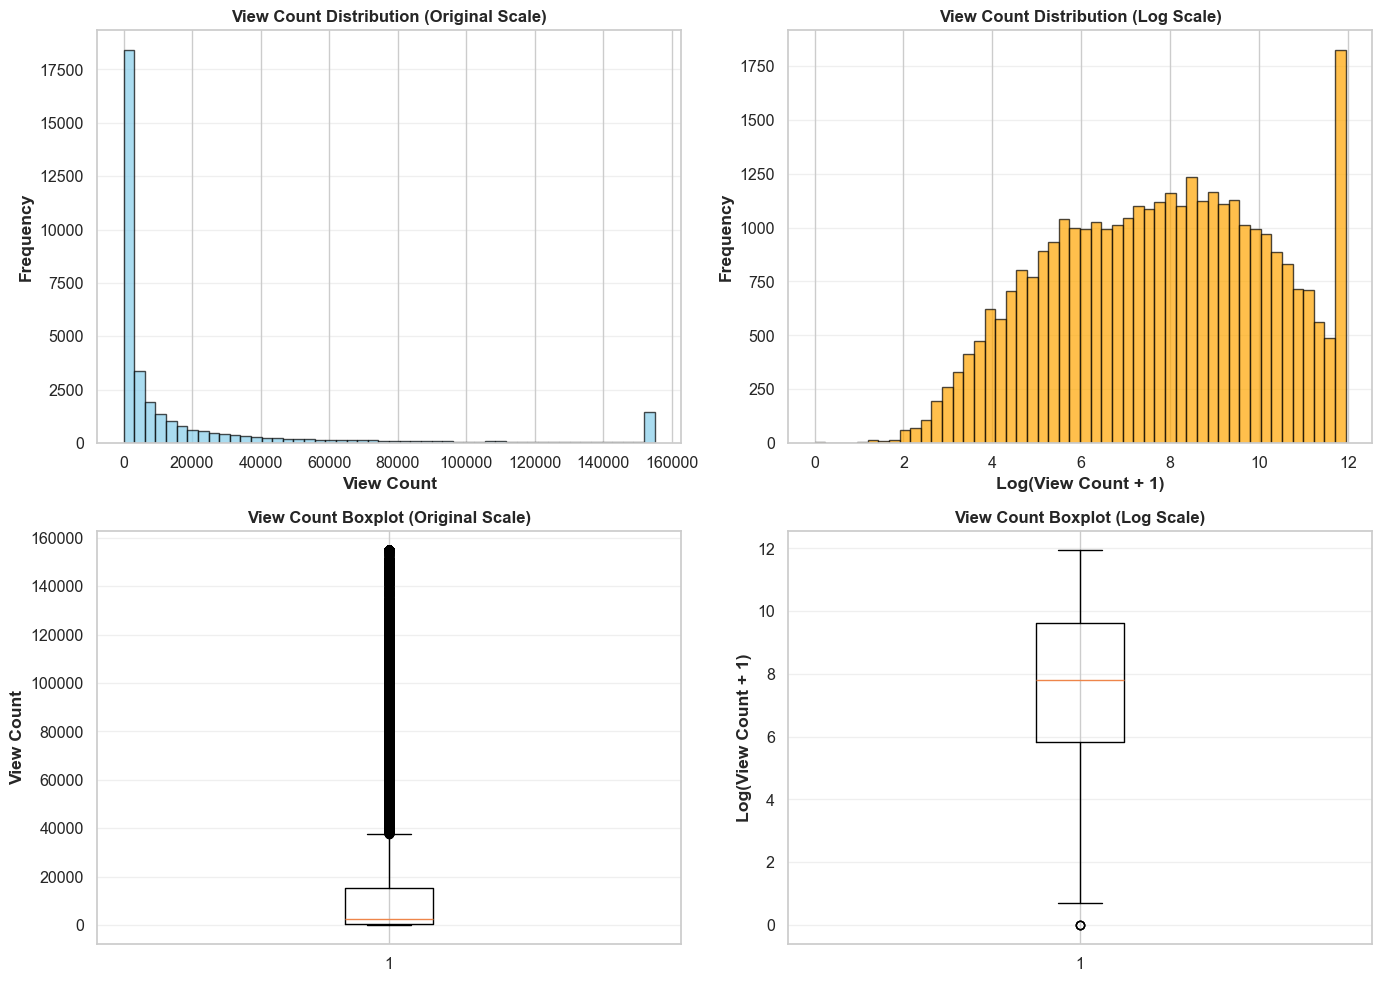

(count     34696.000000
 mean      18852.593584
 std       37496.974496
 min           0.000000
 25%         339.000000
 50%        2483.000000
 75%       15325.250000
 max      154993.500000
 Name: viewCount, dtype: float64,
 count    34696.000000
 mean         7.733601
 std          2.430551
 min          0.000000
 25%          5.828946
 50%          7.817625
 75%          9.637322
 max         11.951145
 Name: viewCount, dtype: float64)

In [20]:
"""
View Count Distribution Analysis
Compare original and log-transformed distributions
Visualize histograms and box plots for outlier detection
"""
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(train['viewCount'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_xlabel('View Count', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('View Count Distribution (Original Scale)', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='y')

axes[0, 1].hist(np.log1p(train['viewCount']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Log(View Count + 1)', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('View Count Distribution (Log Scale)', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='y')

axes[1, 0].boxplot(train['viewCount'], vert=True)
axes[1, 0].set_ylabel('View Count', fontweight='bold')
axes[1, 0].set_title('View Count Boxplot (Original Scale)', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].boxplot(np.log1p(train['viewCount']), vert=True)
axes[1, 1].set_ylabel('Log(View Count + 1)', fontweight='bold')
axes[1, 1].set_title('View Count Boxplot (Log Scale)', fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

log_views = np.log1p(train['viewCount'])
train['viewCount'].describe(), log_views.describe()

In [21]:
"""
Prepare feature matrices for modeling
Drop non-numeric and target columns
Apply median imputation and robust scaling
Select common features between train and test sets
"""
cols_to_drop = ['channelTitle', 'publishedAt', 'likeCount', 'dislikeCount', 'favoriteCount']

X_train = train.drop(columns=cols_to_drop + ['viewCount'], errors='ignore')
X_test = test.drop(columns=cols_to_drop + ['viewCount'], errors='ignore')

X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

common_cols = sorted(list(set(X_train.columns) & set(X_test.columns)))
X_train_df = X_train[common_cols].copy()
X_test_df = X_test[common_cols].copy()

y_train = np.log1p(train['viewCount'].values)
y_test = np.log1p(test['viewCount'].values)

feature_names = X_train_df.columns.tolist()

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_df)
X_test_imputed = imputer.transform(X_test_df)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_train_scaled.shape

(34696, 13)

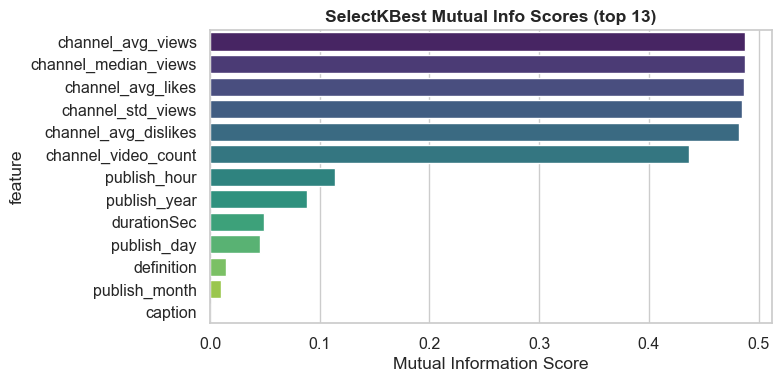

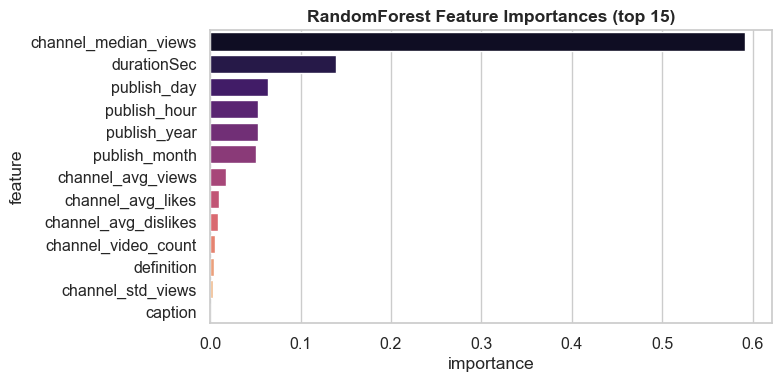

(                 feature     score
 0      channel_avg_views  0.488049
 1   channel_median_views  0.487878
 2      channel_avg_likes  0.486612
 3      channel_std_views  0.484651
 4   channel_avg_dislikes  0.481924
 5    channel_video_count  0.436980
 6           publish_hour  0.113548
 7           publish_year  0.088755
 8            durationSec  0.049224
 9            publish_day  0.045100
 10            definition  0.014568
 11         publish_month  0.009918
 12               caption  0.000117,
                  feature  importance
 4   channel_median_views    0.592100
 8            durationSec    0.139339
 9            publish_day    0.063491
 10          publish_hour    0.052926
 12          publish_year    0.052492
 11         publish_month    0.050317
 3      channel_avg_views    0.017847
 2      channel_avg_likes    0.009496
 1   channel_avg_dislikes    0.008966
 6    channel_video_count    0.005399
 7             definition    0.003989
 5      channel_std_views    0.003638
 

In [22]:
"""
Feature Selection using SelectKBest with Mutual Information
Mutual Information: Measures dependency between features and target, capturing non-linear relationships
Random Forest Feature Importance: Identifies most influential features based on tree splits
"""
k = min(15, X_train_scaled.shape[1])

selector = SelectKBest(score_func=mutual_info_regression, k=k)
selector.fit(X_train_scaled, y_train)

scores = selector.scores_
feat_scores = pd.DataFrame({'feature': feature_names, 'score': scores})
feat_scores = feat_scores.sort_values('score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, max(4, k*0.3)))
sns.barplot(x='score', y='feature', data=feat_scores.head(k), palette='viridis')
plt.title(f'SelectKBest Mutual Info Scores (top {k})', fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

mask = selector.get_support()
selected_features = [feature_names[i] for i, m in enumerate(mask) if m]

X_train_scaled = selector.transform(X_train_scaled)
X_test_scaled = selector.transform(X_test_scaled)
feature_names = selected_features

rf_fs = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_fs.fit(X_train_scaled, y_train)
importances = rf_fs.feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, max(4, len(fi_df.head(15))*0.3)))
sns.barplot(x='importance', y='feature', data=fi_df.head(15), palette='magma')
plt.title('RandomForest Feature Importances (top 15)', fontweight='bold')
plt.tight_layout()
plt.show()

selected_feature_scores = feat_scores
rf_feature_importances = fi_df
feat_scores.head(k), fi_df.head(15)

In [23]:
"""
Re-prepare data for final modeling with all features
Ensures consistent preprocessing pipeline across train and test sets
"""
cols_to_drop = ['channelTitle', 'publishedAt', 'likeCount', 'dislikeCount', 'favoriteCount']
X_train = train.drop(columns=cols_to_drop + ['viewCount'], errors='ignore')
X_test = test.drop(columns=cols_to_drop + ['viewCount'], errors='ignore')

X_train = X_train.select_dtypes(include=[np.number])
X_test = X_test.select_dtypes(include=[np.number])

common_cols = sorted(list(set(X_train.columns) & set(X_test.columns)))
X_train = X_train[common_cols]
X_test = X_test[common_cols]

y_train = np.log1p(train['viewCount'].values)
y_test = np.log1p(test['viewCount'].values)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_train_scaled.shape

(34696, 13)

MULTIPLE REGRESSION MODELS

Train and evaluate diverse model types: Linear, Tree-based, and Gradient Boosting algorithms.

In [24]:
"""
Initialize multiple regression models for comparison
Includes Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and LightGBM
"""
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso (α=0.1)': Lasso(alpha=0.1, max_iter=5000, random_state=RANDOM_STATE),
    'Decision Tree (d=10)': DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest (n=100)': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE),
}

if XGBRegressor:
    models['XGBoost'] = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE, verbosity=0)

if LGBMRegressor:
    models['LightGBM'] = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE, verbose=-1)

list(models.keys())

['Linear Regression',
 'Ridge (α=1.0)',
 'Lasso (α=0.1)',
 'Decision Tree (d=10)',
 'Random Forest (n=100)',
 'Gradient Boosting',
 'XGBoost',
 'LightGBM']

In [25]:
"""
Train all models and evaluate performance metrics
Compute RMSE, MAE, R², and MAPE for train and test sets
Store predictions and metrics for comparison
"""
import warnings
warnings.filterwarnings('ignore')

trained_models = {}
training_results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    test_mape = np.mean(np.abs((y_test - y_test_pred) / (np.abs(y_test) + 1e-6))) * 100
    
    y_test_actual = np.expm1(y_test)
    y_test_pred_actual = np.expm1(y_test_pred)
    actual_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_actual))
    
    training_results[name] = {
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'test_mape': test_mape,
        'actual_rmse': actual_rmse,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
    }

pd.DataFrame(training_results).T[['train_r2', 'test_r2', 'test_rmse']]

,train_r2,test_r2,test_rmse
Linear Regression,0.60577,0.659124,1.398706
Ridge (α=1.0),0.60577,0.659307,1.398331
Lasso (α=0.1),0.592612,0.645152,1.427083
Decision Tree (d=10),0.738191,0.571459,1.568283
Random Forest (n=100),0.870289,0.645775,1.425831
Gradient Boosting,0.712105,0.687638,1.338928
XGBoost,0.70924,0.692644,1.328157
LightGBM,0.711008,0.693057,1.327264


In [26]:
"""
Cross-Validation with 5-Fold Stratified Sampling
Evaluate model generalization using K-Fold cross-validation
Provides robust performance estimates across different data splits
"""
cv_scores = {}
cv_models = {
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, 
                            scoring='neg_mean_squared_error', n_jobs=-1)
    cv_scores[name] = {
        'mean_rmse': np.sqrt(-scores.mean()),
        'std_rmse': np.sqrt(scores.std()),
        'scores': scores
    }

pd.DataFrame({k: {'mean_rmse': v['mean_rmse'], 'std_rmse': v['std_rmse']} 
              for k, v in cv_scores.items()}).T

,mean_rmse,std_rmse
Ridge,1.643362,0.839141
Random Forest,1.677230,0.587359
Gradient Boosting,1.634869,0.764424


LEARNING CURVES

Visualize training and validation performance versus training set size to detect overfitting or underfitting.

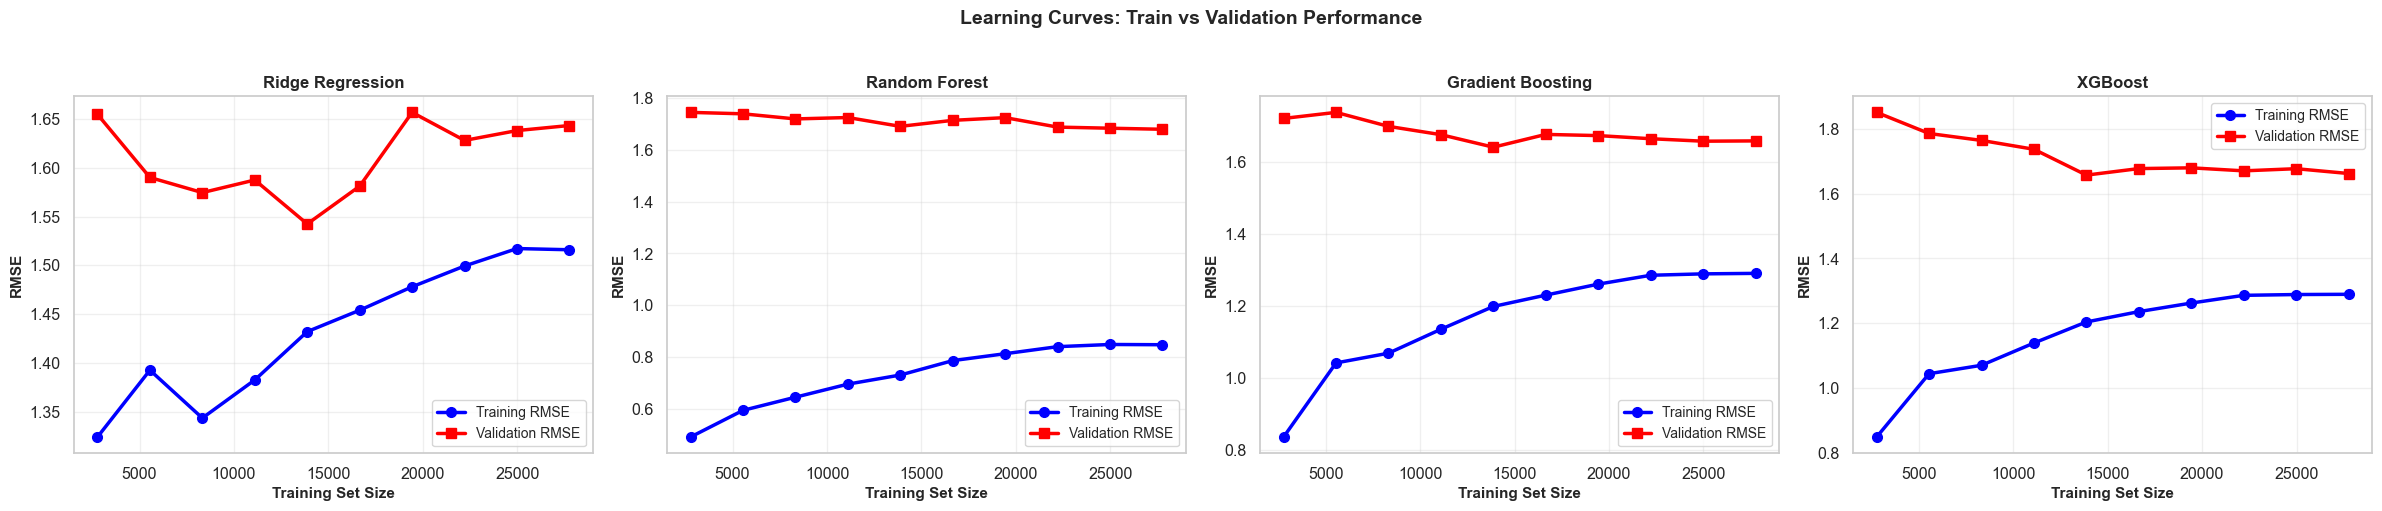

In [27]:
"""
Generate learning curves for top models
Plot training and validation RMSE vs training set size
Helps identify bias-variance tradeoff and data sufficiency
"""
from sklearn.model_selection import learning_curve

selected_for_lc = {
    'Ridge Regression': trained_models['Ridge (α=1.0)'],
    'Random Forest': trained_models['Random Forest (n=100)'],
    'Gradient Boosting': trained_models['Gradient Boosting'],
}

if 'XGBoost' in trained_models:
    selected_for_lc['XGBoost'] = trained_models['XGBoost']

fig, axes = plt.subplots(1, len(selected_for_lc), figsize=(6*len(selected_for_lc), 5))
if len(selected_for_lc) == 1:
    axes = [axes]

for idx, (name, model) in enumerate(selected_for_lc.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    
    train_rmse = np.sqrt(-train_scores.mean(axis=1))
    val_rmse = np.sqrt(-val_scores.mean(axis=1))
    train_std = np.sqrt(-train_scores.std(axis=1))
    val_std = np.sqrt(-val_scores.std(axis=1))
    
    ax = axes[idx]
    ax.plot(train_sizes, train_rmse, 'o-', color='blue', label='Training RMSE', linewidth=2.5, markersize=7)
    ax.fill_between(train_sizes, train_rmse - train_std, train_rmse + train_std, alpha=0.2, color='blue')
    
    ax.plot(train_sizes, val_rmse, 's-', color='red', label='Validation RMSE', linewidth=2.5, markersize=7)
    ax.fill_between(train_sizes, val_rmse - val_std, val_rmse + val_std, alpha=0.2, color='red')
    
    ax.set_xlabel('Training Set Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('RMSE', fontsize=11, fontweight='bold')
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Train vs Validation Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

HYPERPARAMETER TUNING & RMSE PLOTS

Systematic hyperparameter search and visualization of model performance across parameter ranges.

In [28]:
"""
Hyperparameter tuning for Random Forest, Gradient Boosting, and Ridge
Random Forest: max_depth optimization
Gradient Boosting: learning_rate optimization
Ridge: alpha regularization optimization
"""
depths = range(3, 21, 2)
rf_train_rmse = []
rf_test_rmse = []

for depth in depths:
    rf = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    
    y_train_pred = rf.predict(X_train_scaled)
    y_test_pred = rf.predict(X_test_scaled)
    
    rf_train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    rf_test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

learning_rates = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]
gb_train_rmse = []
gb_test_rmse = []

for lr in learning_rates:
    gb = GradientBoostingRegressor(n_estimators=100, learning_rate=lr, max_depth=5, random_state=RANDOM_STATE)
    gb.fit(X_train_scaled, y_train)
    
    y_train_pred = gb.predict(X_train_scaled)
    y_test_pred = gb.predict(X_test_scaled)
    
    gb_train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    gb_test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_train_rmse = []
ridge_test_rmse = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=RANDOM_STATE)
    ridge.fit(X_train_scaled, y_train)
    
    y_train_pred = ridge.predict(X_train_scaled)
    y_test_pred = ridge.predict(X_test_scaled)
    
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

(list(depths)[np.argmin(rf_test_rmse)], learning_rates[np.argmin(gb_test_rmse)], alphas[np.argmin(ridge_test_rmse)])

(3, 0.15, 100)

In [29]:
"""
Grid Search for Random Forest optimization
Systematic search over max_depth, n_estimators, and min_samples_split
Uses 3-fold cross-validation to find optimal parameter combination
"""
param_grid_rf = {
    'max_depth': [7, 10, 15, 20],
    'n_estimators': [50, 100, 150],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_rf.fit(X_train_scaled, y_train)

y_pred_grid = grid_search_rf.predict(X_test_scaled)
grid_rmse = np.sqrt(mean_squared_error(y_test, y_pred_grid))
grid_r2 = r2_score(y_test, y_pred_grid)
grid_mae = mean_absolute_error(y_test, y_pred_grid)

results_df = pd.DataFrame({
    'Best Params': [str(grid_search_rf.best_params_)],
    'Test RMSE': [grid_rmse],
    'Test R2': [grid_r2],
    'Test MAE': [grid_mae]
})

results_df

,Best Params,Test RMSE,Test R2,Test MAE
0,"{'max_depth': 7, 'min_samples_split': 2, 'n_es...",1.383399,0.666544,1.11676


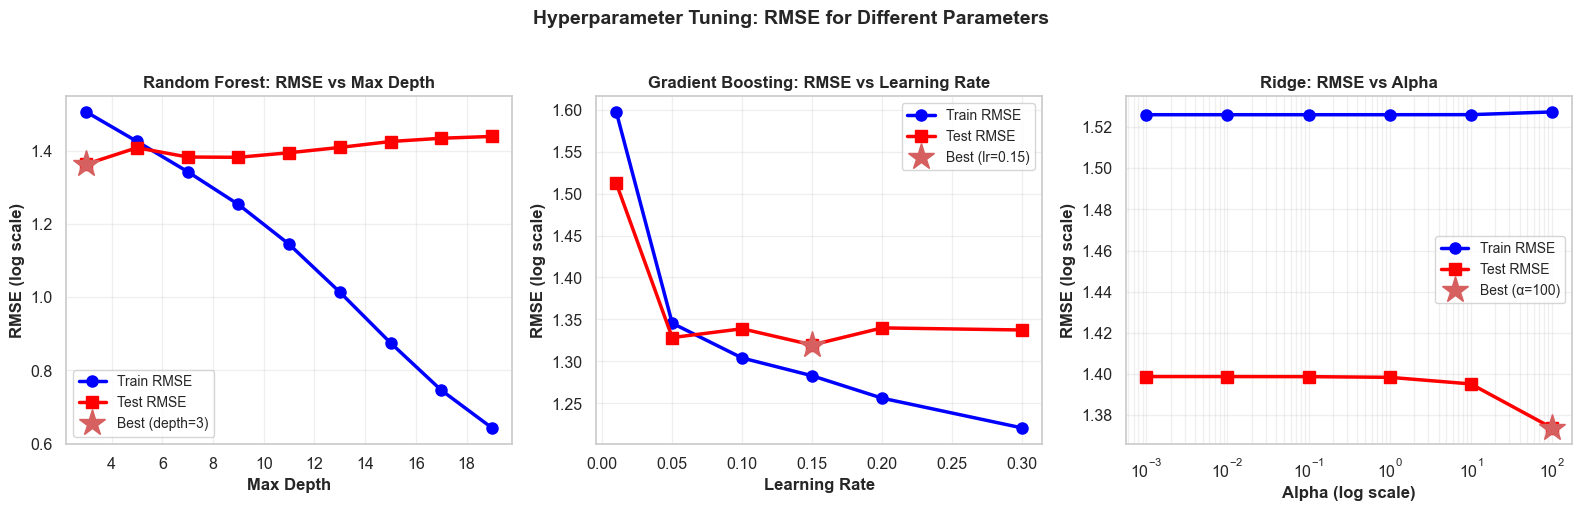

In [30]:
"""
Visualize hyperparameter tuning results
Plot RMSE curves for different parameter values
Identify optimal parameters marked with red stars
"""
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(depths, rf_train_rmse, 'o-', label='Train RMSE', linewidth=2.5, markersize=8, color='blue')
ax.plot(depths, rf_test_rmse, 's-', label='Test RMSE', linewidth=2.5, markersize=8, color='red')
best_depth_idx = np.argmin(rf_test_rmse)
ax.plot(list(depths)[best_depth_idx], rf_test_rmse[best_depth_idx], 'r*', markersize=20, label=f'Best (depth={list(depths)[best_depth_idx]})')
ax.set_xlabel('Max Depth', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log scale)', fontsize=12, fontweight='bold')
ax.set_title('Random Forest: RMSE vs Max Depth', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(learning_rates, gb_train_rmse, 'o-', label='Train RMSE', linewidth=2.5, markersize=8, color='blue')
ax.plot(learning_rates, gb_test_rmse, 's-', label='Test RMSE', linewidth=2.5, markersize=8, color='red')
best_lr_idx = np.argmin(gb_test_rmse)
ax.plot(learning_rates[best_lr_idx], gb_test_rmse[best_lr_idx], 'r*', markersize=20, label=f'Best (lr={learning_rates[best_lr_idx]})')
ax.set_xlabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log scale)', fontsize=12, fontweight='bold')
ax.set_title('Gradient Boosting: RMSE vs Learning Rate', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.semilogx(alphas, ridge_train_rmse, 'o-', label='Train RMSE', linewidth=2.5, markersize=8, color='blue')
ax.semilogx(alphas, ridge_test_rmse, 's-', label='Test RMSE', linewidth=2.5, markersize=8, color='red')
best_alpha_idx = np.argmin(ridge_test_rmse)
ax.semilogx(alphas[best_alpha_idx], ridge_test_rmse[best_alpha_idx], 'r*', markersize=20, label=f'Best (α={alphas[best_alpha_idx]})')
ax.set_xlabel('Alpha (log scale)', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE (log scale)', fontsize=12, fontweight='bold')
ax.set_title('Ridge: RMSE vs Alpha', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Hyperparameter Tuning: RMSE for Different Parameters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<cell_type>markdown</cell_type>## MODEL PERFORMANCE COMPARISON

Comprehensive comparison of all models using R², RMSE, MAE, and MAPE metrics.

In [31]:
"""
Create comprehensive performance comparison table
Display all evaluation metrics for trained models
"""
comparison_df = pd.DataFrame(training_results).T
comparison_df = comparison_df[['train_rmse', 'test_rmse', 'train_mae', 'test_mae', 'train_r2', 'test_r2', 'test_mape', 'actual_rmse']]

for col in comparison_df.columns:
    comparison_df[col] = pd.to_numeric(comparison_df[col], errors='coerce')
comparison_df = comparison_df.round(4)

comparison_df

,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,test_mape,actual_rmse
Linear Regression,1.5261,1.3987,1.2090,1.1231,0.6058,0.6591,111777.6531,24902.8997
Ridge (α=1.0),1.5261,1.3983,1.2090,1.1227,0.6058,0.6593,111744.0082,24898.4142
Lasso (α=0.1),1.5513,1.4271,1.2413,1.1387,0.5926,0.6452,106127.2953,25784.3736
Decision Tree (d=10),1.2436,1.5683,0.9662,1.2250,0.7382,0.5715,96459.4331,27342.0970
Random Forest (n=100),0.8754,1.4258,0.6739,1.1356,0.8703,0.6458,99543.0432,25606.3189
Gradient Boosting,1.3041,1.3389,1.0304,1.0758,0.7121,0.6876,100848.1549,24994.9844
XGBoost,1.3106,1.3282,1.0346,1.0662,0.7092,0.6926,102771.0902,24851.0279
LightGBM,1.3066,1.3273,1.0314,1.0641,0.7110,0.6931,100935.5265,24875.8638


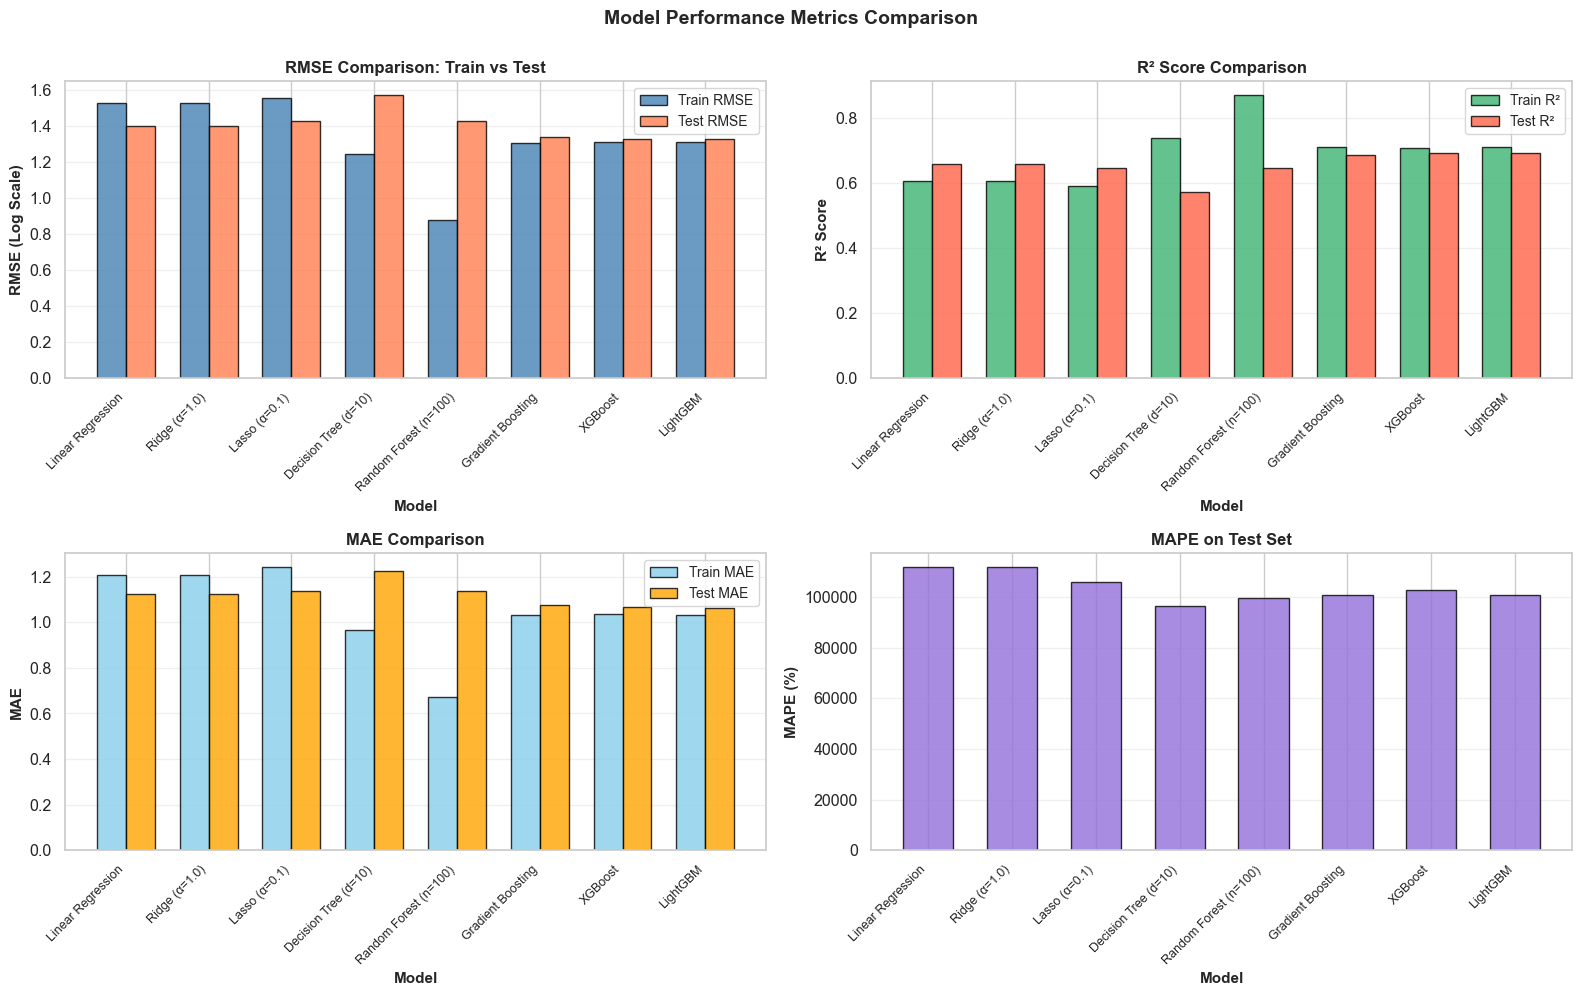

In [32]:
"""
Visualize model performance across multiple metrics
Bar charts comparing RMSE, R², MAE, and MAPE
Highlights differences between train and test performance
"""
model_names = comparison_df.index
x_pos = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.bar(x_pos - width/2, comparison_df['train_rmse'], width, label='Train RMSE', alpha=0.8, color='steelblue', edgecolor='black')
ax.bar(x_pos + width/2, comparison_df['test_rmse'], width, label='Test RMSE', alpha=0.8, color='coral', edgecolor='black')
ax.set_xlabel('Model', fontweight='bold', fontsize=11)
ax.set_ylabel('RMSE (Log Scale)', fontweight='bold', fontsize=11)
ax.set_title('RMSE Comparison: Train vs Test', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 1]
ax.bar(x_pos - width/2, comparison_df['train_r2'], width, label='Train R²', alpha=0.8, color='mediumseagreen', edgecolor='black')
ax.bar(x_pos + width/2, comparison_df['test_r2'], width, label='Test R²', alpha=0.8, color='tomato', edgecolor='black')
ax.set_xlabel('Model', fontweight='bold', fontsize=11)
ax.set_ylabel('R² Score', fontweight='bold', fontsize=11)
ax.set_title('R² Score Comparison', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

ax = axes[1, 0]
ax.bar(x_pos - width/2, comparison_df['train_mae'], width, label='Train MAE', alpha=0.8, color='skyblue', edgecolor='black')
ax.bar(x_pos + width/2, comparison_df['test_mae'], width, label='Test MAE', alpha=0.8, color='orange', edgecolor='black')
ax.set_xlabel('Model', fontweight='bold', fontsize=11)
ax.set_ylabel('MAE', fontweight='bold', fontsize=11)
ax.set_title('MAE Comparison', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
bars = ax.bar(x_pos, comparison_df['test_mape'], alpha=0.8, color='mediumpurple', edgecolor='black', width=0.6)
ax.set_xlabel('Model', fontweight='bold', fontsize=11)
ax.set_ylabel('MAPE (%)', fontweight='bold', fontsize=11)
ax.set_title('MAPE on Test Set', fontweight='bold', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Model Performance Metrics Comparison', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

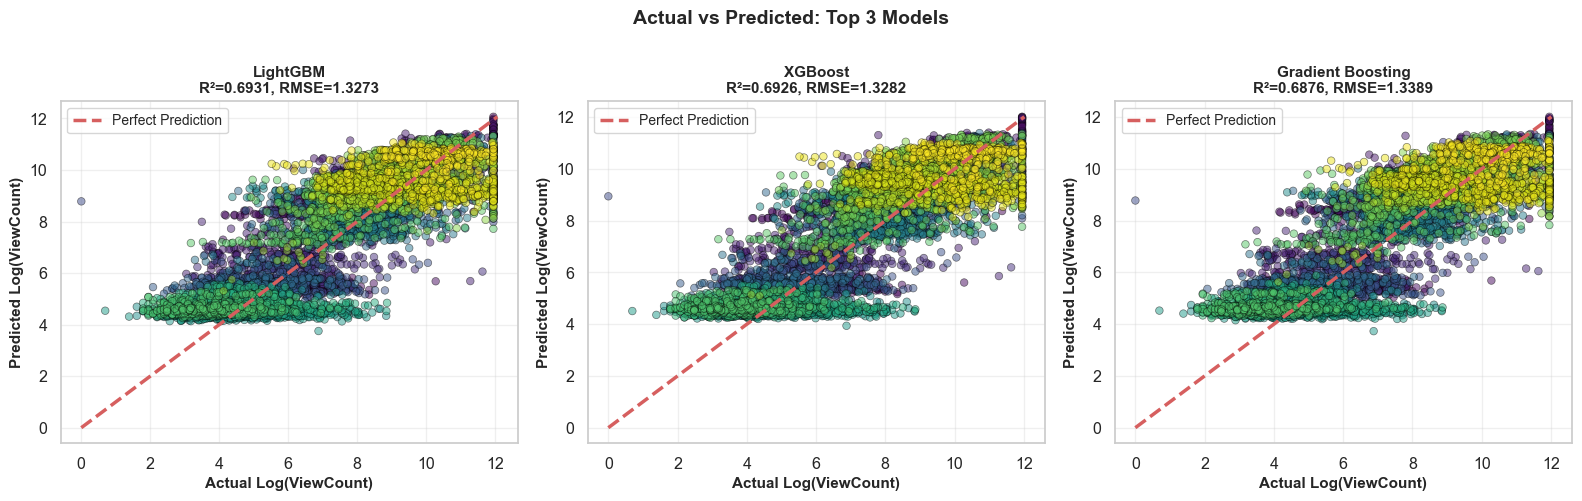

In [33]:
"""
Actual vs Predicted scatter plots for top 3 models
Visualize prediction accuracy with perfect prediction line
Color gradient shows data point density
"""
comparison_df['test_r2'] = pd.to_numeric(comparison_df['test_r2'], errors='coerce')
top_3_models = comparison_df['test_r2'].nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, model_name in enumerate(top_3_models):
    ax = axes[idx]
    y_pred = training_results[model_name]['y_test_pred']
    
    ax.scatter(y_test, y_pred, alpha=0.5, s=30, edgecolors='black', linewidth=0.5, c=range(len(y_test)), cmap='viridis')
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')
    
    ax.set_xlabel('Actual Log(ViewCount)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Predicted Log(ViewCount)', fontweight='bold', fontsize=11)
    test_r2 = comparison_df.loc[model_name, 'test_r2']
    test_rmse = comparison_df.loc[model_name, 'test_rmse']
    ax.set_title(f'{model_name}\nR²={test_r2:.4f}, RMSE={test_rmse:.4f}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted: Top 3 Models', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

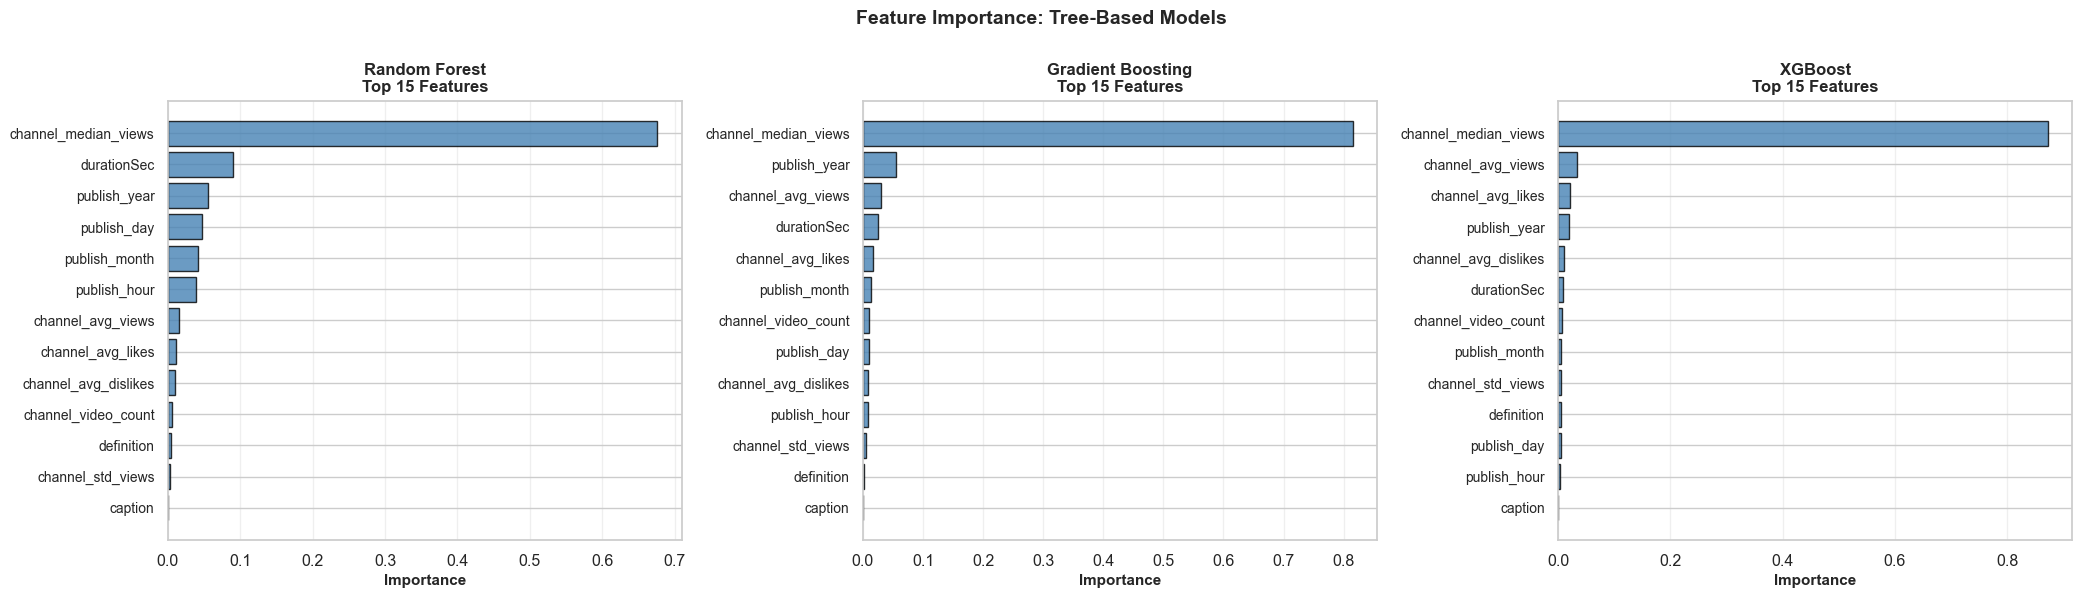

In [34]:
"""
Feature Importance visualization for tree-based models
Shows top 15 most influential features
Helps interpret model decisions and identify key predictors
"""
tree_models_fi = {
    'Random Forest': trained_models['Random Forest (n=100)'],
    'Gradient Boosting': trained_models['Gradient Boosting'],
}

if 'XGBoost' in trained_models:
    tree_models_fi['XGBoost'] = trained_models['XGBoost']

fig, axes = plt.subplots(1, len(tree_models_fi), figsize=(7*len(tree_models_fi), 6))
if len(tree_models_fi) == 1:
    axes = [axes]

feature_names = X_train.columns.tolist()

for idx, (name, model) in enumerate(tree_models_fi.items()):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-15:]
    
    ax = axes[idx]
    ax.barh(range(len(indices)), importances[indices], alpha=0.8, color='steelblue', edgecolor='black')
    ax.set_yticks(range(len(indices)))
    ax.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
    ax.set_xlabel('Importance', fontweight='bold', fontsize=11)
    ax.set_title(f'{name}\nTop 15 Features', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Feature Importance: Tree-Based Models', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

COMPREHENSIVE ANALYSIS & CONCLUSIONS

Detailed interpretation of results and identification of best performing model.

In [35]:
"""
Identify best performing model and rank all models by test R²
Summary of final model performance metrics
"""
best_model = comparison_df['test_r2'].idxmax()
best_r2 = comparison_df.loc[best_model, 'test_r2']
best_rmse = comparison_df.loc[best_model, 'test_rmse']

comparison_df[['test_r2', 'test_rmse', 'test_mae']].sort_values('test_r2', ascending=False)

,test_r2,test_rmse,test_mae
LightGBM,0.6931,1.3273,1.0641
XGBoost,0.6926,1.3282,1.0662
Gradient Boosting,0.6876,1.3389,1.0758
Ridge (α=1.0),0.6593,1.3983,1.1227
Linear Regression,0.6591,1.3987,1.1231
Random Forest (n=100),0.6458,1.4258,1.1356
Lasso (α=0.1),0.6452,1.4271,1.1387
Decision Tree (d=10),0.5715,1.5683,1.2250
